# Add Blood Pressure & Medication Features to NHANES Dataset

**Objective:** Enhance vitamin D prediction model by adding:
- Blood pressure (systolic, diastolic)
- Prescription medications affecting vitamin D metabolism

**Expected Impact:** R² improvement from 0.39 → 0.43-0.45

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Existing Cleaned Dataset

In [ ]:
# Load the existing cleaned NHANES dataset
df_existing = pd.read_csv(r"../data/nhanes_2005_2018_cleaned.csv")

print(f"Existing dataset shape: {df_existing.shape}")
print(f"\nColumns: {list(df_existing.columns)}")
print(f"\nCycles: {sorted(df_existing['cycle'].unique())}")
print(f"\nFirst few rows:")
df_existing.head()

Existing dataset shape: (37393, 23)

Columns: ['ID', 'cycle', 'Age', 'Sex', 'Ethnicity', 'Height_cm', 'Weight_kg', 'BMI', 'vitamin_d_nmol', 'vitamin_d_ng_ml', 'supplement_vitd_mcg', 'dietary_vitd_mcg', 'calories', 'smoked_100_cigarettes', 'vigorous_work', 'moderate_work', 'exam_month', 'season', 'exam_period_numeric', 'age_group', 'sex_label', 'ethnicity_label', 'status']

Cycles: ['2005_2006', '2007_2008', '2009_2010', '2011_2012', '2013_2014', '2015_2016', '2017_2018']

First few rows:


,ID,cycle,Age,Sex,Ethnicity,Height_cm,Weight_kg,BMI,vitamin_d_nmol,vitamin_d_ng_ml,...,smoked_100_cigarettes,vigorous_work,moderate_work,exam_month,season,exam_period_numeric,age_group,sex_label,ethnicity_label,status
0,31131.0,2005_2006,44.0,2.0,4.0,156.0,75.2,30.90,37.5,15.00,...,2.0,1.0,2.0,2.0,Winter_Spring,1.0,31-45,Female,Non-Hispanic Black,Deficient
1,31132.0,2005_2006,70.0,1.0,3.0,167.6,69.5,24.74,73.8,29.52,...,2.0,2.0,2.0,2.0,Winter_Spring,1.0,60+,Male,Non-Hispanic White,Insufficient
2,31134.0,2005_2006,73.0,1.0,3.0,182.4,101.9,30.63,42.2,16.88,...,2.0,3.0,2.0,2.0,Winter_Spring,1.0,60+,Male,Non-Hispanic White,Deficient
3,31143.0,2005_2006,19.0,1.0,3.0,184.0,76.4,22.57,47.1,18.84,...,2.0,2.0,2.0,2.0,Winter_Spring,1.0,18-30,Male,Non-Hispanic White,Deficient
4,31144.0,2005_2006,21.0,1.0,2.0,167.1,69.9,25.03,64.1,25.64,...,2.0,2.0,2.0,2.0,Winter_Spring,1.0,18-30,Male,Other Hispanic,Insufficient


## 2. Extract Blood Pressure Data from BPX Files

Load BPX (examination) files from all cycles and extract:
- `BPXSY1-4` - Systolic BP readings (up to 4 readings)
- `BPXDI1-4` - Diastolic BP readings (up to 4 readings)
- Calculate average of available readings

In [ ]:
from pathlib import Path

# Check the first 200 bytes of each BPX file to verify format
# Note: This assumes raw NHANES .XPT files are in the data directory structure
base_data_dir = r'../data'

for cycle_name, suffix in cycles:
    bpx_file = f'{base_data_dir}/nhanes_{cycle_name}/BPX_{suffix}.XPT'
    if not Path(bpx_file).exists():
        print(f"✗ {cycle_name}: File not found - {bpx_file}")
        continue
    with open(bpx_file, 'rb') as f:
        header = f.read(200)
    print(f"\n{cycle_name} - {bpx_file}:")
    print(header[:200])
    # If it's a text file, print as string
    try:
        print(header.decode('utf-8'))
    except Exception:
        print("  (Binary content not decodable as UTF-8)")


2005_2006 - E:/University/FYP/SolMate/SolMate/data/nhanes_2005_2006/BPX_D.XPT:
b'HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000000000000000000000  SAS     SAS     SASLIB  9.1     XP_PRO\x00N                        20AUG07:09:41:5620AUG07:09:41:56                        '
HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000000000000000000000  SAS     SAS     SASLIB  9.1     XP_PRO N                        20AUG07:09:41:5620AUG07:09:41:56                        

2007_2008 - E:/University/FYP/SolMate/SolMate/data/nhanes_2007_2008/BPX_E.XPT:
b'HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000000000000000000000  SAS     SAS     SASLIB  9.2     XP_PRO\x00\x00                        15JUN09:12:32:4215JUN09:12:32:42                        '
HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000000000000000000000  SAS     SAS     SASLIB  9.2     XP_PRO                          15JUN09:12:32:4215JUN09:12:32:42                        

2009_2010 - E:/Unive

In [ ]:
# Define cycles
cycles = [
    ('2005_2006', 'D'),
    ('2007_2008', 'E'),
    ('2009_2010', 'F'),
    ('2011_2012', 'G'),
    ('2013_2014', 'H'),
    ('2015_2016', 'I'),
    ('2017_2018', 'J')
]

bp_data_list = []

# Set the correct base data directory (relative to notebooks folder)
base_data_dir = r'../data'

for cycle_name, suffix in cycles:
    bpx_file = f'{base_data_dir}/nhanes_{cycle_name}/BPX_{suffix}.XPT'
    
    # Check if file exists
    from pathlib import Path
    if not Path(bpx_file).exists():
        print(f"✗ {cycle_name}: File not found - {bpx_file}")
        continue
    
    try:
        # Load BPX data (examination blood pressure measurements)
        df_bp = pd.read_sas(bpx_file)
        
        print(f"  Loaded {cycle_name}: {len(df_bp)} records, {len(df_bp.columns)} columns")
        
        # Extract relevant columns (SEQN is subject ID)
        # Systolic and diastolic readings
        systolic_cols = [col for col in df_bp.columns if col.startswith('BPXSY')]
        diastolic_cols = [col for col in df_bp.columns if col.startswith('BPXDI')]
        
        print(f"  Found BP columns: {len(systolic_cols)} systolic, {len(diastolic_cols)} diastolic")
        
        if len(systolic_cols) == 0 or len(diastolic_cols) == 0:
            print(f"  Skipping {cycle_name} - no valid BP columns found\n")
            continue
        
        # Keep all available BP columns
        available_cols = ['SEQN'] + systolic_cols + diastolic_cols
        df_bp_subset = df_bp[available_cols].copy()
        
        # Calculate average systolic and diastolic
        df_bp_subset['systolic_bp'] = df_bp_subset[systolic_cols].mean(axis=1, skipna=True)
        df_bp_subset['diastolic_bp'] = df_bp_subset[diastolic_cols].mean(axis=1, skipna=True)
        
        # Add cycle identifier
        df_bp_subset['cycle'] = cycle_name
        
        # Keep only SEQN, cycle, and averaged BP values
        df_bp_final = df_bp_subset[['SEQN', 'cycle', 'systolic_bp', 'diastolic_bp']].copy()
        
        bp_data_list.append(df_bp_final)
        
        print(f"✓ {cycle_name}: {len(df_bp_final)} records processed successfully\n")
        
    except Exception as e:
        print(f"✗ {cycle_name}: ERROR - {str(e)}\n")
        import traceback
        traceback.print_exc()

# Check if we have any data
if len(bp_data_list) == 0:
    raise ValueError("No BP data was successfully loaded! Check file paths and formats above.")

# Combine all cycles
df_bp_all = pd.concat(bp_data_list, ignore_index=True)

print(f"\n{'='*60}")
print(f"Total BP records: {len(df_bp_all):,}")
print(f"Systolic BP - Mean: {df_bp_all['systolic_bp'].mean():.1f}, Std: {df_bp_all['systolic_bp'].std():.1f}")
print(f"Diastolic BP - Mean: {df_bp_all['diastolic_bp'].mean():.1f}, Std: {df_bp_all['diastolic_bp'].std():.1f}")
print(f"Missing BP values: {df_bp_all[['systolic_bp', 'diastolic_bp']].isnull().sum().to_dict()}")
print(f"{'='*60}")

  Loaded 2005_2006: 9950 records, 28 columns
  Found BP columns: 4 systolic, 4 diastolic
✓ 2005_2006: 9950 records processed successfully

  Loaded 2007_2008: 9762 records, 27 columns
  Found BP columns: 4 systolic, 4 diastolic
✓ 2007_2008: 9762 records processed successfully

  Loaded 2009_2010: 10253 records, 27 columns
  Found BP columns: 4 systolic, 4 diastolic
✓ 2009_2010: 10253 records processed successfully

  Loaded 2011_2012: 9338 records, 27 columns
  Found BP columns: 4 systolic, 4 diastolic
✓ 2011_2012: 9338 records processed successfully

  Loaded 2013_2014: 9813 records, 23 columns
  Found BP columns: 4 systolic, 4 diastolic
✓ 2013_2014: 9813 records processed successfully

  Loaded 2015_2016: 9544 records, 21 columns
  Found BP columns: 4 systolic, 4 diastolic
✓ 2015_2016: 9544 records processed successfully

  Loaded 2017_2018: 8704 records, 21 columns
  Found BP columns: 4 systolic, 4 diastolic
✓ 2017_2018: 8704 records processed successfully


Total BP records: 67,364

## 3. Extract Prescription Medication Data

Identify medications that affect vitamin D metabolism:
- **Glucocorticoids** (e.g., prednisone, dexamethasone) - deplete vitamin D
- **Anticonvulsants** (e.g., phenytoin, carbamazepine) - increase vitamin D metabolism
- **Cholestyramine** - reduces vitamin D absorption
- **Orlistat** (weight loss) - reduces fat-soluble vitamin absorption

In [16]:
# Medication drug codes/names that affect vitamin D
# Based on RxNorm codes commonly found in NHANES

glucocorticoid_keywords = ['prednisone', 'prednisolone', 'dexamethasone', 'methylprednisolone', 
                           'hydrocortisone', 'cortisone', 'budesonide', 'triamcinolone']

anticonvulsant_keywords = ['phenytoin', 'carbamazepine', 'phenobarbital', 'primidone',
                           'oxcarbazepine', 'dilantin', 'tegretol', 'carbatrol']

cholesterol_keywords = ['cholestyramine', 'questran', 'prevalite', 'colestipol']

weightloss_keywords = ['orlistat', 'xenical', 'alli']

print("Medication keywords defined.")
print(f"  Glucocorticoids: {len(glucocorticoid_keywords)} keywords")
print(f"  Anticonvulsants: {len(anticonvulsant_keywords)} keywords")
print(f"  Cholesterol binders: {len(cholesterol_keywords)} keywords")
print(f"  Weight loss: {len(weightloss_keywords)} keywords")

Medication keywords defined.
  Glucocorticoids: 8 keywords
  Anticonvulsants: 8 keywords
  Cholesterol binders: 4 keywords
  Weight loss: 3 keywords


In [ ]:
med_data_list = []

# Set the correct base data directory (relative to notebooks folder)
base_data_dir = r'../data'

for cycle_name, suffix in cycles:
    rxq_file = f'{base_data_dir}/nhanes_{cycle_name}/RXQ_RX_{suffix}.XPT'
    
    try:
        # Load prescription medication data
        df_rx = pd.read_sas(rxq_file)
        
        # RXDDRUG or RXDDRGID contains drug name/code
        drug_col = None
        if 'RXDDRUG' in df_rx.columns:
            drug_col = 'RXDDRUG'
        elif 'RXDDRGID' in df_rx.columns:
            drug_col = 'RXDDRGID'
        
        if drug_col is None:
            print(f"✗ {cycle_name}: No drug name column found")
            continue
        
        # Convert drug names to lowercase for matching
        df_rx['drug_lower'] = df_rx[drug_col].astype(str).str.lower()
        
        # Create medication flags for each subject
        med_flags = df_rx.groupby('SEQN').agg({
            'drug_lower': lambda x: '|'.join(x.dropna().astype(str))
        }).reset_index()
        
        med_flags.columns = ['SEQN', 'all_medications']
        
        # Check for each medication type
        med_flags['takes_glucocorticoid'] = med_flags['all_medications'].apply(
            lambda x: int(any(keyword in x for keyword in glucocorticoid_keywords))
        )
        
        med_flags['takes_anticonvulsant'] = med_flags['all_medications'].apply(
            lambda x: int(any(keyword in x for keyword in anticonvulsant_keywords))
        )
        
        med_flags['takes_cholesterol_binder'] = med_flags['all_medications'].apply(
            lambda x: int(any(keyword in x for keyword in cholesterol_keywords))
        )
        
        med_flags['takes_weightloss_drug'] = med_flags['all_medications'].apply(
            lambda x: int(any(keyword in x for keyword in weightloss_keywords))
        )
        
        # Combined flag: any vitamin D-affecting medication
        med_flags['takes_vitd_affecting_med'] = (
            (med_flags['takes_glucocorticoid'] == 1) | 
            (med_flags['takes_anticonvulsant'] == 1) |
            (med_flags['takes_cholesterol_binder'] == 1) |
            (med_flags['takes_weightloss_drug'] == 1)
        ).astype(int)
        
        # Add cycle
        med_flags['cycle'] = cycle_name
        
        # Drop the concatenated medications string
        med_flags_final = med_flags.drop('all_medications', axis=1)
        
        med_data_list.append(med_flags_final)
        
        # Summary statistics
        n_glucocorticoid = med_flags['takes_glucocorticoid'].sum()
        n_anticonvulsant = med_flags['takes_anticonvulsant'].sum()
        n_any = med_flags['takes_vitd_affecting_med'].sum()
        
        print(f"✓ {cycle_name}: {len(df_rx)} prescriptions, {len(med_flags)} subjects")
        print(f"  Glucocorticoid: {n_glucocorticoid}, Anticonvulsant: {n_anticonvulsant}, Any: {n_any}")
        
    except Exception as e:
        print(f"✗ {cycle_name}: {e}")

# Combine all cycles
df_med_all = pd.concat(med_data_list, ignore_index=True)

print(f"\n{'='*60}")
print(f"Total subjects with medication data: {len(df_med_all):,}")
print(f"\nMedication prevalence:")
print(f"  Glucocorticoids: {df_med_all['takes_glucocorticoid'].sum():,} ({df_med_all['takes_glucocorticoid'].mean()*100:.1f}%)")
print(f"  Anticonvulsants: {df_med_all['takes_anticonvulsant'].sum():,} ({df_med_all['takes_anticonvulsant'].mean()*100:.1f}%)")
print(f"  Cholesterol binders: {df_med_all['takes_cholesterol_binder'].sum():,} ({df_med_all['takes_cholesterol_binder'].mean()*100:.1f}%)")
print(f"  Weight loss drugs: {df_med_all['takes_weightloss_drug'].sum():,} ({df_med_all['takes_weightloss_drug'].mean()*100:.1f}%)")
print(f"  Any VitD-affecting med: {df_med_all['takes_vitd_affecting_med'].sum():,} ({df_med_all['takes_vitd_affecting_med'].mean()*100:.1f}%)")
print(f"{'='*60}")

✓ 2005_2006: 18005 prescriptions, 10348 subjects
  Glucocorticoid: 220, Anticonvulsant: 61, Any: 284
✓ 2007_2008: 20516 prescriptions, 10149 subjects
  Glucocorticoid: 227, Anticonvulsant: 65, Any: 294
✓ 2009_2010: 20905 prescriptions, 10537 subjects
  Glucocorticoid: 257, Anticonvulsant: 59, Any: 319
✓ 2011_2012: 18704 prescriptions, 9756 subjects
  Glucocorticoid: 223, Anticonvulsant: 36, Any: 260
✓ 2013_2014: 20194 prescriptions, 10175 subjects
  Glucocorticoid: 202, Anticonvulsant: 51, Any: 259
✓ 2015_2016: 19647 prescriptions, 9971 subjects
  Glucocorticoid: 206, Anticonvulsant: 38, Any: 248
✓ 2017_2018: 19643 prescriptions, 9254 subjects
  Glucocorticoid: 220, Anticonvulsant: 56, Any: 281

Total subjects with medication data: 70,190

Medication prevalence:
  Glucocorticoids: 1,555 (2.2%)
  Anticonvulsants: 366 (0.5%)
  Cholesterol binders: 49 (0.1%)
  Weight loss drugs: 3 (0.0%)
  Any VitD-affecting med: 1,945 (2.8%)


## 4. Merge New Features with Existing Dataset

In [20]:
# Merge BP data
df_merged = df_existing.merge(
    df_bp_all[['SEQN', 'cycle', 'systolic_bp', 'diastolic_bp']], 
    left_on=['ID', 'cycle'], 
    right_on=['SEQN', 'cycle'], 
    how='left'
)

# Drop duplicate SEQN column
df_merged = df_merged.drop('SEQN', axis=1)

print(f"After BP merge: {df_merged.shape}")
print(f"  BP data available: {df_merged['systolic_bp'].notna().sum():,} / {len(df_merged):,} ({df_merged['systolic_bp'].notna().mean()*100:.1f}%)")

# Merge medication data
df_merged = df_merged.merge(
    df_med_all, 
    left_on=['ID', 'cycle'], 
    right_on=['SEQN', 'cycle'], 
    how='left'
)

# Drop duplicate SEQN column
df_merged = df_merged.drop('SEQN', axis=1)

# Fill missing medication flags with 0 (no medication)
med_cols = ['takes_glucocorticoid', 'takes_anticonvulsant', 'takes_cholesterol_binder', 
            'takes_weightloss_drug', 'takes_vitd_affecting_med']

for col in med_cols:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].fillna(0).astype(int)

print(f"\nAfter medication merge: {df_merged.shape}")
print(f"  Medication data available: {df_merged['takes_vitd_affecting_med'].sum():,} subjects taking VitD-affecting meds")

print(f"\n{'='*60}")
print(f"FINAL MERGED DATASET")
print(f"{'='*60}")
print(f"Shape: {df_merged.shape}")
print(f"\nNew columns added:")
new_cols = ['systolic_bp', 'diastolic_bp'] + med_cols
for col in new_cols:
    if col in df_merged.columns:
        print(f"  ✓ {col}")

After BP merge: (37393, 25)
  BP data available: 35,978 / 37,393 (96.2%)

After medication merge: (37393, 30)
  Medication data available: 1,198 subjects taking VitD-affecting meds

FINAL MERGED DATASET
Shape: (37393, 30)

New columns added:
  ✓ systolic_bp
  ✓ diastolic_bp
  ✓ takes_glucocorticoid
  ✓ takes_anticonvulsant
  ✓ takes_cholesterol_binder
  ✓ takes_weightloss_drug
  ✓ takes_vitd_affecting_med


## 5. Data Quality Check

In [21]:
# Check missing values for new features
print("Missing values in new features:")
print(df_merged[new_cols].isnull().sum())

print("\nBasic statistics for BP:")
print(df_merged[['systolic_bp', 'diastolic_bp']].describe())

print("\nMedication flag distribution:")
print(df_merged[med_cols].sum())

Missing values in new features:
systolic_bp                 1415
diastolic_bp                1415
takes_glucocorticoid           0
takes_anticonvulsant           0
takes_cholesterol_binder       0
takes_weightloss_drug          0
takes_vitd_affecting_med       0
dtype: int64

Basic statistics for BP:
        systolic_bp  diastolic_bp
count  35978.000000  3.597800e+04
mean     123.621834  6.958914e+01
std       18.604991  1.304367e+01
min       64.666667  5.397605e-79
25%      110.666667  6.200000e+01
50%      120.666667  7.000000e+01
75%      133.333333  7.733333e+01
max      270.000000  1.386667e+02

Medication flag distribution:
takes_glucocorticoid         895
takes_anticonvulsant         272
takes_cholesterol_binder      44
takes_weightloss_drug          3
takes_vitd_affecting_med    1198
dtype: int64


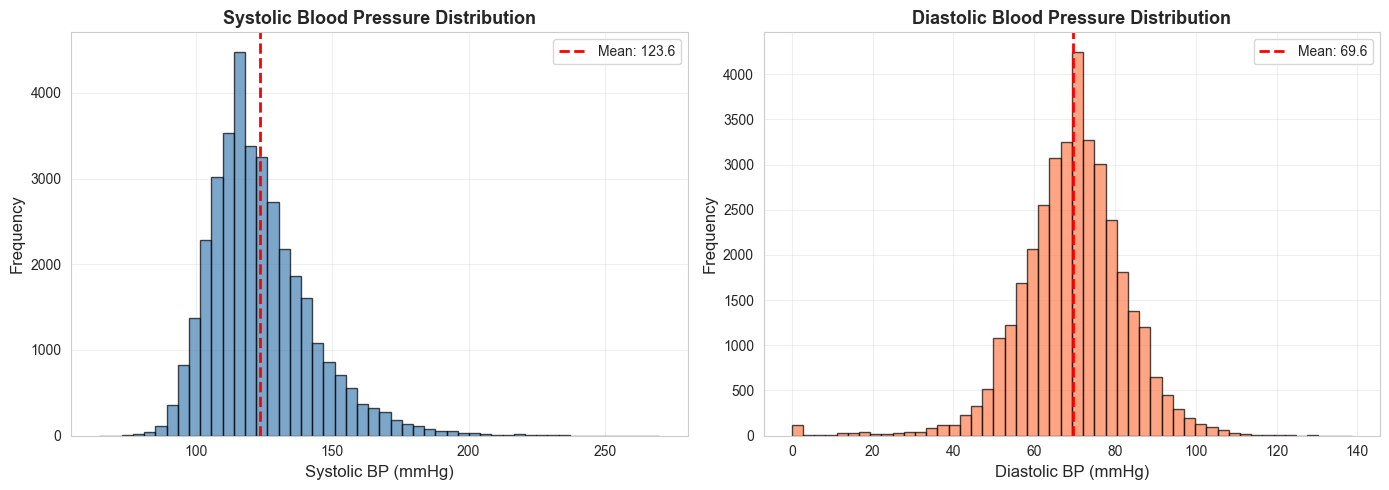

In [22]:
# Visualize BP distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Systolic BP
axes[0].hist(df_merged['systolic_bp'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_merged['systolic_bp'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_merged['systolic_bp'].mean():.1f}")
axes[0].set_xlabel('Systolic BP (mmHg)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Systolic Blood Pressure Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Diastolic BP
axes[1].hist(df_merged['diastolic_bp'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(df_merged['diastolic_bp'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_merged['diastolic_bp'].mean():.1f}")
axes[1].set_xlabel('Diastolic BP (mmHg)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Diastolic Blood Pressure Distribution', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

Check correlation between new features and vitamin D levels

CORRELATION WITH VITAMIN D LEVELS
                 Feature  Correlation  Abs_Correlation
            diastolic_bp    -0.044319         0.044319
takes_vitd_affecting_med     0.032941         0.032941
    takes_glucocorticoid     0.032613         0.032613
             systolic_bp     0.030778         0.030778
takes_cholesterol_binder     0.019591         0.019591
    takes_anticonvulsant     0.006767         0.006767
   takes_weightloss_drug    -0.003001         0.003001


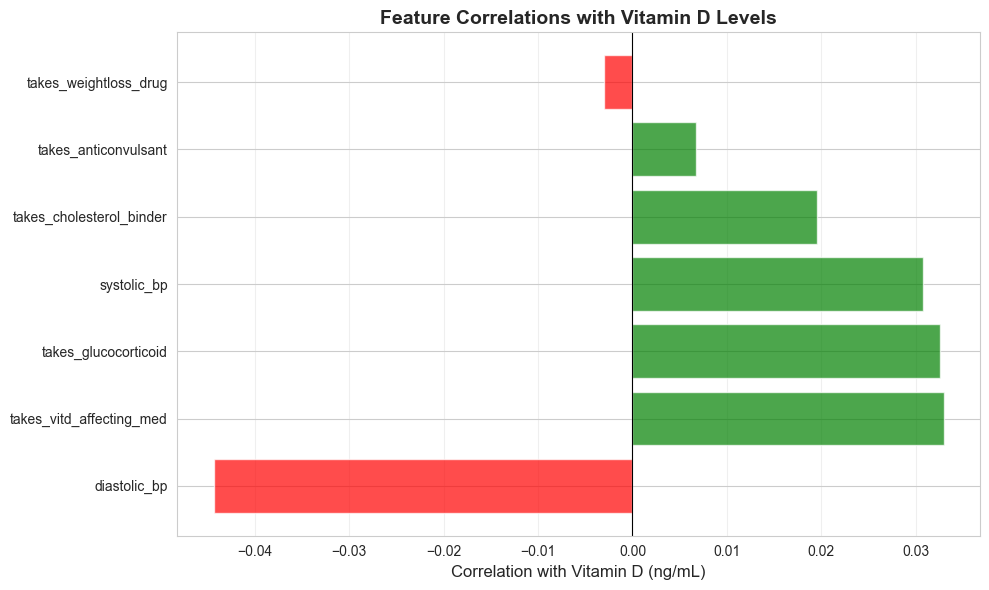

In [23]:
# Calculate correlations with vitamin D
correlations = {}
for col in new_cols:
    if col in df_merged.columns:
        corr = df_merged[[col, 'vitamin_d_ng_ml']].corr().iloc[0, 1]
        correlations[col] = corr

# Sort by absolute correlation
corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()
corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)

print("="*60)
print("CORRELATION WITH VITAMIN D LEVELS")
print("="*60)
print(corr_df.to_string(index=False))
print("="*60)

# Visualize correlations
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in corr_df['Correlation']]
plt.barh(range(len(corr_df)), corr_df['Correlation'], color=colors, alpha=0.7)
plt.yticks(range(len(corr_df)), corr_df['Feature'])
plt.xlabel('Correlation with Vitamin D (ng/mL)', fontsize=12)
plt.title('Feature Correlations with Vitamin D Levels', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 7. Save Enhanced Dataset

In [ ]:
# Save the enhanced dataset
output_file = '../data/nhanes_2005_2018_with_bp_medication.csv'
df_merged.to_csv(output_file, index=False)

print("="*60)
print("DATASET SAVED")
print("="*60)
print(f"File: {output_file}")
print(f"Shape: {df_merged.shape}")
print(f"Total features: {len(df_merged.columns)}")
print(f"\nOriginal features: {len(df_existing.columns)}")
print(f"New features added: {len(df_merged.columns) - len(df_existing.columns)}")
print("="*60)
print("\n✓ Ready for model training!")
print("Next step: Update 07_optimized_model.ipynb to use this new dataset")

DATASET SAVED
File: E:/University/FYP/SolMate/SolMate/data/nhanes_2005_2018_with_bp_medication.csv
Shape: (37393, 30)
Total features: 30

Original features: 23
New features added: 7

✓ Ready for model training!
Next step: Update 07_optimized_model.ipynb to use this new dataset
